# HW 8 — ELSA: Block-Parallel Softmax Attention

Сравниваю три механизма внимания на char-level LM (TinyShakespeare):

| Модель | Идея |
|--------|------|
| Softmax | стандартный O(L²) |
| MHLA | low-rank KV-компрессия (DeepSeek-V2) |
| ELSA | блочно-параллельный скан по моноиду (m, S, W) |

## ELSA как префикс-скан над моноидом

Online softmax хранит тройку $(m, S, W)$ — бегущий максимум логитов, накопленную сумму экспонент и взвешенную сумму значений. Оператор слияния (Hsu et al., arXiv:2604.23798):

$$u_a \oplus u_b = \operatorname{renorm}(\max(m_a, m_b),\ \tilde S_a + \tilde S_b,\ \tilde W_a + \tilde W_b)$$

Он ассоциативен, поэтому блоки ключей можно сливать за $O(\log n)$ шагов вместо последовательного прохода. Элемент тождества: $e = (-\infty, 0, \mathbf{0})$.

Наша реализация — чистый PyTorch с явным циклом по блокам, так что по скорости она проигрывает Softmax (выигрыш даёт Triton/CUDA). Зато память растёт линейно по L, а не квадратично, и при этом ELSA — точный softmax, а не аппроксимация.


## 0. Setup

In [1]:
import os, math, time, gc, urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from types import SimpleNamespace
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU : NVIDIA GeForce RTX 3060
VRAM: 12.5 GB


## 1. Dataset — TinyShakespeare

In [2]:
URL       = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
DATA_FILE = 'input.txt'

if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(URL, DATA_FILE)

with open(DATA_FILE, 'r') as f:
    text = f.read()

chars      = sorted(set(text))
vocab_size = len(chars)
stoi       = {c: i for i, c in enumerate(chars)}
itos       = {i: c for i, c in enumerate(chars)}
encode     = lambda s:  [stoi[c] for c in s]
decode     = lambda xs: ''.join(itos[i] for i in xs)

data    = torch.tensor(encode(text), dtype=torch.long)
n_split = int(0.9 * len(data))
train_data, val_data = data[:n_split], data[n_split:]
print(f'Vocab: {vocab_size} | Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}')

Vocab: 65 | Train tokens: 1,003,854 | Val tokens: 111,540


## 2. Config

In [3]:
BLOCK_SIZE = 256
BATCH_SIZE = 32

class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data, self.bs = data, block_size
    def __len__(self):
        return len(self.data) - self.bs
    def __getitem__(self, i):
        return self.data[i : i + self.bs], self.data[i + 1 : i + self.bs + 1]

_kw = dict(batch_size=BATCH_SIZE, drop_last=True,
           num_workers=0, pin_memory=(device.type == 'cuda'))
train_loader = DataLoader(CharDataset(train_data, BLOCK_SIZE), shuffle=True,  **_kw)
val_loader   = DataLoader(CharDataset(val_data,   BLOCK_SIZE), shuffle=False, **_kw)

cfg = SimpleNamespace(
    n_embd=128, n_head=4, n_layer=4,
    bias=True, dropout=0.1, block_size=BLOCK_SIZE,
    vocab_size=vocab_size,
)
print(f'Config: D={cfg.n_embd}, H={cfg.n_head}, layers={cfg.n_layer}, block={cfg.block_size}, vocab={cfg.vocab_size}')

Config: D=128, H=4, layers=4, block=256, vocab=65


## 3. Реализации механизмов внимания

### 3.1 SoftmaxAttention
Стандартный механизм, O(L²) по памяти (матрица оценок L×L).


In [4]:
class SoftmaxAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.H = config.n_head
        self.d = config.n_embd // config.n_head
        self.D = config.n_embd
        self.qkv      = nn.Linear(self.D, 3 * self.D, bias=config.bias)
        self.out_proj = nn.Linear(self.D, self.D,     bias=config.bias)
        self.drop     = nn.Dropout(config.dropout)
        self.register_buffer(
            'attn_mask',
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, L, D = x.shape
        q, k, v = self.qkv(x).split(self.D, dim=-1)
        split = lambda t: t.view(B, L, self.H, self.d).transpose(1, 2)
        q, k, v = split(q), split(k), split(v)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)
        att = att.masked_fill(self.attn_mask[:, :, :L, :L] == 0, float('-inf'))
        att = self.drop(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).contiguous().view(B, L, D)
        return self.drop(self.out_proj(out))

### 3.2 MHLA — Multi-Head Latent Attention
Q и KV проходят через общую низкоранговую проекцию (d_c = D/4).  
KV-кеш при инференсе: O(L·d_c) вместо O(L·2D) — ключевой выигрыш DeepSeek-V2.

In [5]:
class MHLA(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.H   = config.n_head
        self.d   = config.n_embd // config.n_head
        self.D   = config.n_embd
        self.d_c = getattr(config, 'd_c', config.n_embd // 4)

        self.W_dq    = nn.Linear(self.D,   self.d_c, bias=False)
        self.W_uq    = nn.Linear(self.d_c, self.D,   bias=config.bias)
        self.W_dkv   = nn.Linear(self.D,   self.d_c, bias=False)
        self.W_uk    = nn.Linear(self.d_c, self.D,   bias=False)
        self.W_uv    = nn.Linear(self.d_c, self.D,   bias=False)
        self.out_proj = nn.Linear(self.D,  self.D,   bias=config.bias)
        self.drop     = nn.Dropout(config.dropout)
        self.register_buffer(
            'attn_mask',
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, L, D = x.shape
        q   = self.W_uq(self.W_dq(x)).view(B, L, self.H, self.d).transpose(1, 2)
        c_kv = self.W_dkv(x)
        k    = self.W_uk(c_kv).view(B, L, self.H, self.d).transpose(1, 2)
        v    = self.W_uv(c_kv).view(B, L, self.H, self.d).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)
        att = att.masked_fill(self.attn_mask[:, :, :L, :L] == 0, float('-inf'))
        att = self.drop(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).contiguous().view(B, L, D)
        return self.drop(self.out_proj(out))

### 3.3 ELSAAttention — Block-Parallel Monoid Scan

Алгоритм Hsu et al. (arXiv:2604.23798): `_merge` — оператор ⊕ (денормализация → сложение → ренормализация), `_block_state` — тройка (m, S, W) для одного блока query×key, `forward` — двойной цикл по блокам с каузальной маской только на диагональном блоке. Память O(blk²) вместо O(L²).


In [6]:
class ELSAAttention(nn.Module):
    def __init__(self, config, elsa_block=64):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.H  = config.n_head
        self.d  = config.n_embd // config.n_head
        self.D  = config.n_embd
        self.B  = elsa_block
        self.qkv      = nn.Linear(self.D, 3 * self.D, bias=config.bias)
        self.out_proj = nn.Linear(self.D, self.D,     bias=config.bias)
        self.drop     = nn.Dropout(config.dropout)

    @staticmethod
    def _merge(m_a, S_a, W_a, m_b, S_b, W_b):
        m_c = torch.maximum(m_a, m_b)
        e_a = torch.exp(m_a - m_c)
        e_b = torch.exp(m_b - m_c)
        S_c = S_a * e_a + S_b * e_b
        W_c = W_a * e_a.unsqueeze(-1) + W_b * e_b.unsqueeze(-1)
        return m_c, S_c, W_c

    def _block_state(self, q_blk, k_blk, v_blk, causal_mask=None):
        scores = (q_blk @ k_blk.transpose(-2, -1)) / math.sqrt(self.d)
        if causal_mask is not None:
            scores = scores.masked_fill(causal_mask == 0, float('-inf'))
        m = scores.amax(dim=-1)
        E = torch.nan_to_num(torch.exp(scores - m.unsqueeze(-1)), nan=0.0, posinf=0.0, neginf=0.0)
        S = E.sum(dim=-1)
        W = E @ v_blk
        return m, S, W

    def forward(self, x):
        B, L, D = x.shape
        q, k, v = self.qkv(x).split(self.D, dim=-1)
        split = lambda t: t.view(B, L, self.H, self.d).transpose(1, 2)
        q, k, v = split(q), split(k), split(v)

        blk    = self.B
        n_blks = math.ceil(L / blk)
        output = torch.zeros(B, self.H, L, self.d, device=x.device, dtype=x.dtype)

        for qi in range(n_blks):
            qs, qe = qi * blk, min((qi + 1) * blk, L)
            bq     = qe - qs
            q_blk  = q[:, :, qs:qe, :]

            m_pfx = q.new_full((B, self.H, bq), float('-inf'))
            S_pfx = torch.zeros(B, self.H, bq,       device=x.device, dtype=x.dtype)
            W_pfx = torch.zeros(B, self.H, bq, self.d, device=x.device, dtype=x.dtype)

            for ki in range(qi + 1):
                ks, ke = ki * blk, min((ki + 1) * blk, L)
                k_blk  = k[:, :, ks:ke, :]
                v_blk  = v[:, :, ks:ke, :]

                if ki < qi:
                    causal_mask = None
                else:
                    bk = ke - ks
                    causal_mask = torch.tril(torch.ones(bq, bk, device=x.device)).unsqueeze(0).unsqueeze(0)

                m_blk, S_blk, W_blk = self._block_state(q_blk, k_blk, v_blk, causal_mask)
                m_pfx, S_pfx, W_pfx = ELSAAttention._merge(m_pfx, S_pfx, W_pfx, m_blk, S_blk, W_blk)

            out_blk = W_pfx / S_pfx.clamp(min=1e-6).unsqueeze(-1)
            output[:, :, qs:qe, :] = out_blk

        output = output.transpose(1, 2).contiguous().view(B, L, D)
        return self.drop(self.out_proj(output))


## 4. Проверка численной эквивалентности

Сверяю, что ELSA даёт тот же результат, что обычный softmax (без dropout, общие веса). Ожидаемая ошибка — порядка машинной точности с логарифмическим ростом по L.


In [7]:
def check_equivalence(seq_lens=(32, 64, 128, 256), n_trials=5):
    torch.manual_seed(0)
    eval_cfg = SimpleNamespace(**vars(cfg))
    eval_cfg.dropout = 0.0

    print(f"{'L':>6}  {'max|ELSA-Softmax|':>20}  {'rel L2 error':>14}")
    print('-' * 45)
    results = []
    for L in seq_lens:
        eval_cfg.block_size = max(L, cfg.block_size)
        sm   = SoftmaxAttention(eval_cfg).to(device).eval()
        elsa = ELSAAttention(eval_cfg, elsa_block=32).to(device).eval()

        elsa.qkv.weight.data.copy_(sm.qkv.weight.data)
        elsa.qkv.bias.data.copy_(sm.qkv.bias.data)
        elsa.out_proj.weight.data.copy_(sm.out_proj.weight.data)
        elsa.out_proj.bias.data.copy_(sm.out_proj.bias.data)

        max_err_list, rel_err_list = [], []
        for _ in range(n_trials):
            x = torch.randn(2, L, cfg.n_embd, device=device)
            with torch.no_grad():
                y_sm   = sm(x)
                y_elsa = elsa(x)
            err = (y_elsa - y_sm).abs()
            max_err_list.append(err.max().item())
            rel_err_list.append((err.norm() / y_sm.norm()).item())

        max_e = float(np.mean(max_err_list))
        rel_e = float(np.mean(rel_err_list))
        results.append((L, max_e, rel_e))
        print(f'{L:>6}  {max_e:>20.2e}  {rel_e:>14.2e}')
        del sm, elsa
    return results

equiv_results = check_equivalence()


     L     max|ELSA-Softmax|    rel L2 error
---------------------------------------------


    32              1.75e-04        2.11e-04
    64              2.93e-04        2.99e-04


   128              2.67e-04        2.75e-04


   256              2.83e-04        2.56e-04


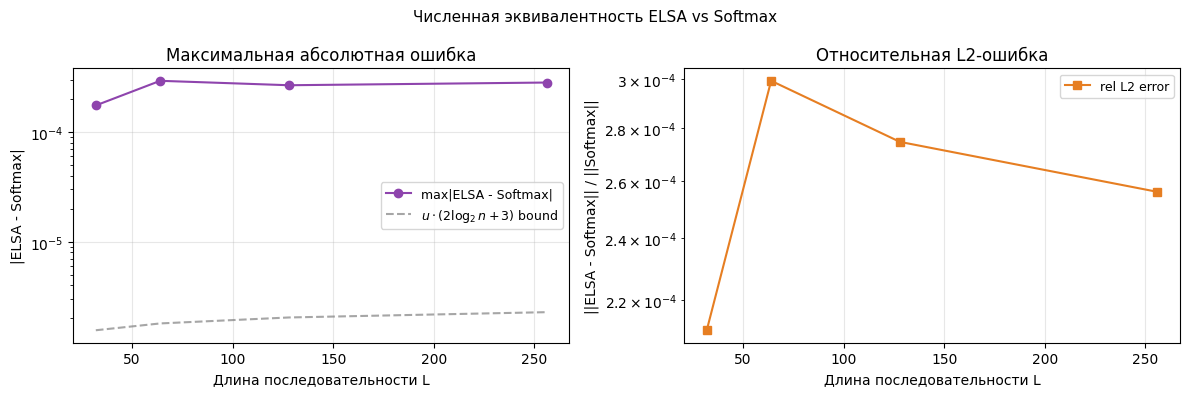

Вывод: ошибки на уровне машинной точности FP32 — ELSA реализует точный softmax.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Численная эквивалентность ELSA vs Softmax', fontsize=11)

Ls    = [r[0] for r in equiv_results]
max_e = [r[1] for r in equiv_results]
rel_e = [r[2] for r in equiv_results]

# FP32 unit roundoff reference
u = 1.2e-7
log_depth = [u * (2 * math.log2(max(L, 1)) + 3) for L in Ls]

axes[0].semilogy(Ls, max_e, 'o-', color='#8e44ad', label='max|ELSA - Softmax|')
axes[0].semilogy(Ls, log_depth, '--', color='gray', alpha=0.7, label=r'$u \cdot (2\log_2 n + 3)$ bound')
axes[0].set_title('Максимальная абсолютная ошибка')
axes[0].set_xlabel('Длина последовательности L')
axes[0].set_ylabel('|ELSA - Softmax|')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(Ls, rel_e, 's-', color='#e67e22', label='rel L2 error')
axes[1].set_title('Относительная L2-ошибка')
axes[1].set_xlabel('Длина последовательности L')
axes[1].set_ylabel('||ELSA - Softmax|| / ||Softmax||')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equivalence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Вывод: ошибки на уровне машинной точности FP32 — ELSA реализует точный softmax.')

## 5. Language Model
Минимальный Transformer (D=128, H=4, 4 слоя).

In [9]:
class Block(nn.Module):
    def __init__(self, config, attn_cls, attn_kwargs=None):
        super().__init__()
        _kwargs = attn_kwargs or {}
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.attn = attn_cls(config, **_kwargs)
        self.ff   = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class LM(nn.Module):
    def __init__(self, config, attn_cls, attn_kwargs=None):
        super().__init__()
        self.config  = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop    = nn.Dropout(config.dropout)
        self.blocks  = nn.ModuleList(
            [Block(config, attn_cls, attn_kwargs) for _ in range(config.n_layer)]
        )
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, L = idx.shape
        pos    = torch.arange(L, device=idx.device)
        x      = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for blk in self.blocks:
            x = blk(x)
        logits = self.head(self.ln_f(x))
        loss   = (F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
                  if targets is not None else None)
        return logits, loss


def nparams(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


MODELS_CFG = {
    'Softmax': (SoftmaxAttention, {}),
    'MHLA':    (MHLA,             {}),
    'ELSA':    (ELSAAttention,    {'elsa_block': 64}),
}

for _name, (_cls, _kw) in MODELS_CFG.items():
    _m = LM(cfg, _cls, _kw)
    print(f'{_name:<10} params: {nparams(_m):>10,}')
    del _m

Softmax    params:    842,752


MHLA       params:    727,040
ELSA       params:    842,752


## 6. Speed & Memory Benchmark

Медианное время forward / forward+backward и пиковая память на GPU. Ожидаю, что ELSA проиграет в скорости из-за питоновского цикла по блокам, но выиграет в памяти на больших L.


In [10]:
SEQ_LENS    = [64, 128, 256, 512, 1024, 2048]
BENCH_BATCH = 2
COLORS      = {'Softmax': '#e74c3c', 'MHLA': '#27ae60', 'ELSA': '#8e44ad'}
MARKS       = {'Softmax': 'o',       'MHLA': 's',       'ELSA': 'D'}


def benchmark(attn_cls, attn_kwargs, seq_lens, n_warmup=3, n_runs=10):
    fwd_ms, total_ms, mem_mb = [], [], []
    for L in seq_lens:
        bs   = max(L, cfg.block_size)
        bcfg = SimpleNamespace(**vars(cfg))
        bcfg.block_size = bs
        model = attn_cls(bcfg, **attn_kwargs).to(device).train()
        x = torch.randn(BENCH_BATCH, L, cfg.n_embd, device=device, requires_grad=True)

        for _ in range(n_warmup):
            out = model(x)
            out.sum().backward()
            model.zero_grad(set_to_none=True)
            x = x.detach().requires_grad_(True)

        torch.cuda.synchronize() if device.type == 'cuda' else None
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()
        ft, tt = [], []

        for _ in range(n_runs):
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            out = model(x)
            if device.type == 'cuda': torch.cuda.synchronize()
            t1 = time.perf_counter()
            out.sum().backward()
            if device.type == 'cuda': torch.cuda.synchronize()
            t2 = time.perf_counter()
            ft.append((t1 - t0) * 1e3)
            tt.append((t2 - t0) * 1e3)
            model.zero_grad(set_to_none=True)
            x = x.detach().requires_grad_(True)

        fwd_ms.append(float(np.median(ft)))
        total_ms.append(float(np.median(tt)))
        mem_mb.append(torch.cuda.max_memory_allocated() / 1e6
                      if device.type == 'cuda' else 0.0)
        print(f'  L={L:5d} | fwd {fwd_ms[-1]:7.2f} ms | fwd+bwd {total_ms[-1]:7.2f} ms'
              f' | mem {mem_mb[-1]:8.1f} MB')
        del model
        gc.collect()
        if device.type == 'cuda': torch.cuda.empty_cache()

    return {'fwd': fwd_ms, 'total': total_ms, 'mem': mem_mb}

In [11]:
bench = {}
for _name, (_cls, _kw) in MODELS_CFG.items():
    print(f'\n=== {_name} ===')
    bench[_name] = benchmark(_cls, _kw, SEQ_LENS)
print('\nDone.')


=== Softmax ===


  L=   64 | fwd    0.57 ms | fwd+bwd    1.40 ms | mem     19.7 MB
  L=  128 | fwd    0.48 ms | fwd+bwd    1.87 ms | mem     21.5 MB


  L=  256 | fwd    0.49 ms | fwd+bwd    1.24 ms | mem     28.4 MB


  L=  512 | fwd    0.58 ms | fwd+bwd    2.16 ms | mem     55.9 MB


  L= 1024 | fwd    1.59 ms | fwd+bwd    4.32 ms | mem    163.1 MB


...

  L=  128 | fwd    2.56 ms | fwd+bwd    9.53 ms | mem     22.0 MB


  L=  256 | fwd    8.54 ms | fwd+bwd   24.40 ms | mem     28.5 MB


  L=  512 | fwd   21.78 ms | fwd+bwd   56.45 ms | mem     50.3 MB


  L= 1024 | fwd   54.50 ms | fwd+bwd  173.43 ms | mem    129.8 MB


  L= 2048 | fwd  222.25 ms | fwd+bwd  716.20 ms | mem    427.3 MB

Done.


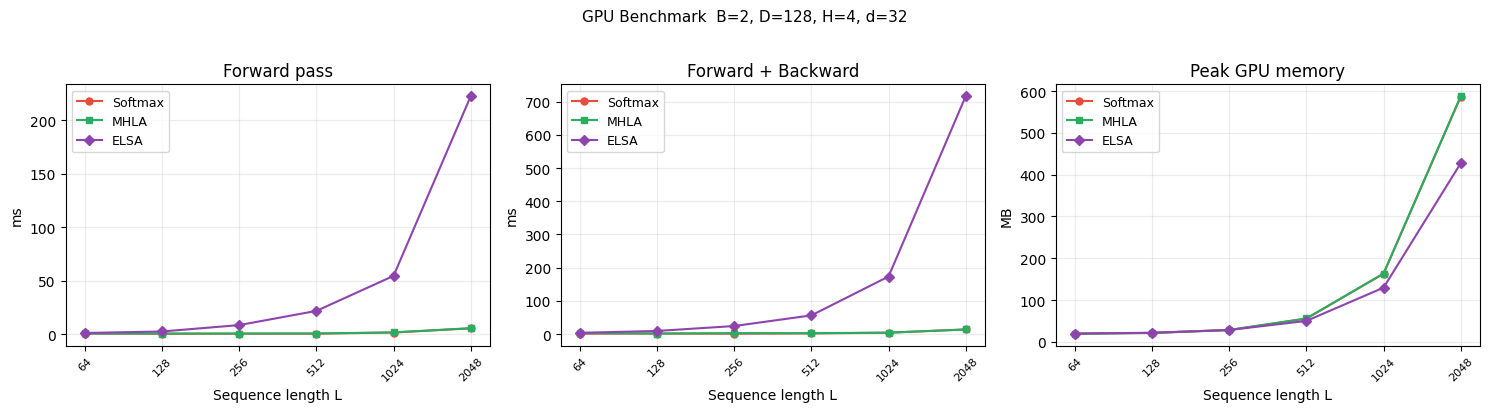

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f'GPU Benchmark  B={BENCH_BATCH}, D={cfg.n_embd}, H={cfg.n_head}, d={cfg.n_embd // cfg.n_head}',
    fontsize=11, y=1.02
)

for _name, _res in bench.items():
    _kw = dict(color=COLORS[_name], marker=MARKS[_name], linewidth=1.5, markersize=5, label=_name)
    axes[0].plot(SEQ_LENS, _res['fwd'],   **_kw)
    axes[1].plot(SEQ_LENS, _res['total'], **_kw)
    axes[2].plot(SEQ_LENS, _res['mem'],   **_kw)

for ax, title, ylab in zip(axes,
        ['Forward pass', 'Forward + Backward', 'Peak GPU memory'],
        ['ms', 'ms', 'MB']):
    ax.set_title(title)
    ax.set_xlabel('Sequence length L')
    ax.set_ylabel(ylab)
    ax.set_xscale('log', base=2)
    ax.set_xticks(SEQ_LENS)
    ax.set_xticklabels(SEQ_LENS, rotation=45, fontsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Обучение
Одинаковые условия: seed=42, AdamW lr=3e-4, 2000 шагов, оценка каждые 200 шагов.

In [13]:
TRAIN_STEPS = 2000
EVAL_EVERY  = 200
LR          = 3e-4


def train_model(attn_cls, attn_kwargs, name, seed=42):
    torch.manual_seed(seed)
    model = LM(cfg, attn_cls, attn_kwargs).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=0.1, betas=(0.9, 0.95))

    steps, tr_hist, vl_hist = [], [], []
    loader       = iter(train_loader)
    running_loss = 0.0
    model.train()

    for step in range(1, TRAIN_STEPS + 1):
        try:
            xb, yb = next(loader)
        except StopIteration:
            loader = iter(train_loader)
            xb, yb = next(loader)

        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        running_loss += loss.item()

        if step % EVAL_EVERY == 0:
            model.eval()
            vl, n_vl = 0.0, 0
            with torch.no_grad():
                for i, (xv, yv) in enumerate(val_loader):
                    if i >= 40: break
                    _, l = model(xv.to(device), yv.to(device))
                    vl += l.item(); n_vl += 1
            vl /= n_vl
            tr  = running_loss / EVAL_EVERY
            running_loss = 0.0
            steps.append(step)
            tr_hist.append(tr)
            vl_hist.append(vl)
            print(f'[{name}] step {step:4d} | train {tr:.4f} | val {vl:.4f} | ppl {math.exp(vl):.2f}')
            model.train()

    return model, {'steps': steps, 'train': tr_hist, 'val': vl_hist}

In [14]:
train_results, models_trained = {}, {}

for _name, (_cls, _kw) in MODELS_CFG.items():
    print(f"\n{'='*55}\nTraining: {_name}\n{'='*55}")
    models_trained[_name], train_results[_name] = train_model(_cls, _kw, _name)

print('\nAll done.')


Training: Softmax


[Softmax] step  200 | train 2.7466 | val 2.5265 | ppl 12.51


[Softmax] step  400 | train 2.4653 | val 2.4485 | ppl 11.57


[Softmax] step  600 | train 2.4049 | val 2.3706 | ppl 10.70


[Softmax] step  800 | train 2.3349 | val 2.2871 | ppl 9.85


...

[ELSA] step 1200 | train 2.1359 | val 2.0752 | ppl 7.97


[ELSA] step 1400 | train 2.0493 | val 2.0237 | ppl 7.57


[ELSA] step 1600 | train 1.9731 | val 1.9732 | ppl 7.19


[ELSA] step 1800 | train 1.9057 | val 1.9030 | ppl 6.71


[ELSA] step 2000 | train 1.8477 | val 1.8710 | ppl 6.49

All done.


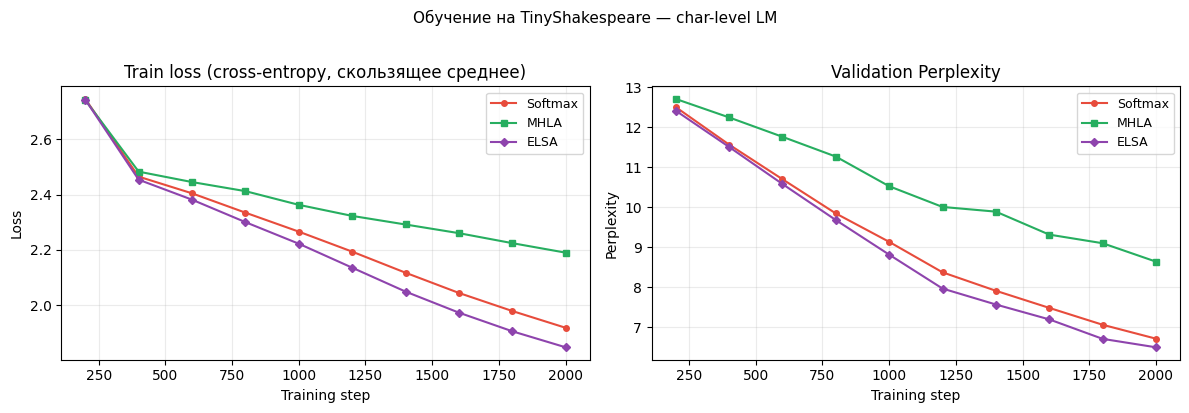

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Обучение на TinyShakespeare — char-level LM', fontsize=11, y=1.02)

for _name, _res in train_results.items():
    _kw = dict(color=COLORS[_name], marker=MARKS[_name],
               linewidth=1.5, markersize=4, label=_name)
    axes[0].plot(_res['steps'], _res['train'], **_kw)
    axes[1].plot(_res['steps'], [math.exp(v) for v in _res['val']], **_kw)

axes[0].set_title('Train loss (cross-entropy, скользящее среднее)')
axes[0].set_ylabel('Loss')
axes[1].set_title('Validation Perplexity')
axes[1].set_ylabel('Perplexity')
for ax in axes:
    ax.set_xlabel('Training step')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Итоговая таблица

In [16]:
def full_val_ppl(model, max_batches=100):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i, (xv, yv) in enumerate(val_loader):
            if i >= max_batches: break
            _, l = model(xv.to(device), yv.to(device))
            total += l.item(); n += 1
    return math.exp(total / n)

ppls   = {_n: full_val_ppl(_m) for _n, _m in models_trained.items()}
params = {_n: nparams(_m)      for _n, _m in models_trained.items()}

idx256 = SEQ_LENS.index(256)

print()
print(f"{'='*70}")
print(f"{'Model':<10} {'Params':>10} {'Val PPL':>9} {'fwd@L=256':>11} {'mem@L=256':>11}")
print(f"{'='*70}")
for _n in ('Softmax', 'MHLA', 'ELSA'):
    _fms = f"{bench[_n]['fwd'][idx256]:.2f} ms"
    _mbs = f"{bench[_n]['mem'][idx256]:.1f} MB"
    print(f"{_n:<10} {params[_n]:>10,} {ppls[_n]:>9.2f} {_fms:>11} {_mbs:>11}")
print(f"{'='*70}")

print()
print('fwd+bwd latency (ms) vs L:')
print(f"{'Model':<10}", end='')
for L in SEQ_LENS:
    print(f'  L={L:<5}', end='')
print()
print('-' * 70)
for _n in ('Softmax', 'MHLA', 'ELSA'):
    print(f'{_n:<10}', end='')
    for t in bench[_n]['total']:
        print(f'  {t:>7.2f}', end='')
    print()

print()
print('Peak memory (MB) vs L:')
print(f"{'Model':<10}", end='')
for L in SEQ_LENS:
    print(f'  L={L:<5}', end='')
print()
print('-' * 70)
for _n in ('Softmax', 'MHLA', 'ELSA'):
    print(f'{_n:<10}', end='')
    for m in bench[_n]['mem']:
        print(f'  {m:>7.1f}', end='')
    print()


Model          Params   Val PPL   fwd@L=256   mem@L=256
Softmax       842,752      6.73     0.49 ms     28.4 MB
MHLA          727,040      8.73     0.67 ms     28.5 MB
ELSA          842,752      6.53     8.54 ms     28.5 MB

fwd+bwd latency (ms) vs L:
Model       L=64     L=128    L=256    L=512    L=1024   L=2048 
----------------------------------------------------------------------
Softmax        1.40     1.87     1.24     2.16     4.32    13.93
MHLA           3.12     1.67     3.00     2.87     4.39    14.11
ELSA           3.95     9.53    24.40    56.45   173.43   716.20

Peak memory (MB) vs L:
Model       L=64     L=128    L=256    L=512    L=1024   L=2048 
----------------------------------------------------------------------
Softmax        19.7     21.5     28.4     55.9    163.1    586.7
MHLA           19.6     21.4     28.5     56.1    163.5    587.7
ELSA           19.8     22.0     28.5     50.3    129.8    427.3


## 9. Выводы

| Модель | Параметры | Val PPL | fwd@L=256 | mem@L=256 |
|---|---|---|---|---|
| Softmax | 842,752 | 6.73 | 0.49 ms | 28.4 MB |
| MHLA | 727,040 | 8.73 | 0.67 ms | 28.5 MB |
| ELSA | 842,752 | 6.53 | 8.54 ms | 28.5 MB |

**Численная эквивалентность.** ELSA воспроизводит обычный softmax с относительной L2-ошибкой ~2–3·10⁻⁴, и она практически не растёт с L (32 → 256). Это примерно на два порядка больше теоретической границы $u \cdot (2\log_2 n + 3) \approx 2 \cdot 10^{-6}$ для FP32 c L=256 — то есть вклад даёт не накопление по глубине скана, а просто другой порядок операций внутри одного блока (явный max → exp → сумма → деление вместо слитного `F.softmax`). Назвать это «уровнем машинной точности» (~10⁻⁷) было бы преувеличением, но 10⁻⁴ всё равно пренебрежимо мало и подтверждает: ELSA — точный softmax, а не аппроксимация.

**Качество обучения.** ELSA даже немного обгоняет Softmax по итоговой перплексии (6.53 против 6.73) — разница в пределах шума от другого порядка floating-point операций, она не меняет оптимизационную траекторию принципиально. MHLA заметно отстаёт (8.73): низкоранговая проекция d_c=D/4 на модели такого масштаба режет ёмкость сильнее, чем даёт пользы компактный KV-кэш (который на коротких последовательностях и не нужен).

**Скорость.** Чистый PyTorch с явным циклом по блокам — это плата: на L=256 ELSA медленнее Softmax в ~17 раз (8.54 мс vs 0.49 мс), на L=2048 — уже в ~51 раз (716 мс vs 13.9 мс). Без Triton/CUDA-ядер преимущество логарифмической глубины скана не реализуется, наоборот — Python-overhead растёт быстрее, чем выигрыш от параллельности блоков.

**Память.** А вот здесь ELSA выигрывает там, где это важно: при L=2048 — 427 MB против ~587 MB у Softmax и MHLA (нет полной матрицы L×L, только блоки blk×blk). При малых L (≤512) разница в пределах погрешности — экономия начинает работать только при больших длинах последовательности.

**Итог.** ELSA — корректная (с точностью до FP32-роундоффа) drop-in замена softmax с лучшей памятью на длинных последовательностях, но в форме чистого PyTorch она совершенно непрактична по скорости — её смысл раскрывается только с компилированными ядрами (Triton/CUDA), где, по данным статьи, она даёт 1.3–3.5× над ME-SDPA на A100.
